# Graduate Employability Prediction and Recommendation System

This notebook consolidates the analyses from the `employability-ai-system/notebooks` folder into a single, clean data science workflow. The goal is to align the work with the project objectives and make it ready for submission and presentation.

## Project objectives
- Develop an AI-based system to predict graduate employability and recommend skills that improve employment outcomes.
- Analyze how graduate profiles and skills relate to employment outcomes.
- Train predictive models for employment probability.
- Identify key employability factors with feature importance.
- Design skill recommendations using model insights.
- Evaluate model performance and fairness, especially across regions.
- Provide recommendations for universities and policymakers.

## Notebook structure
This notebook follows a structured data science pipeline from EDA to modeling and recommendations:
1. Data loading and initial inspection
2. Data cleaning and preprocessing
3. Exploratory data analysis (EDA)
4. Feature engineering and target definition
5. Model training and selection
6. Model evaluation and fairness analysis
7. Skill recommendation system design
8. Application integration and actionable insights

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, recall_score, roc_auc_score, roc_curve, r2_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 100
pd.options.display.width = 120

## 1. Data loading and initial inspection
Load the graduate employability dataset from the `employability-ai-system` folder and inspect the available columns.

In [3]:
data_path = '../../employability-ai-system/data/raw/global_graduate_employability_index.csv'
df = pd.read_csv(data_path)

print('Dataset shape:', df.shape)
print()
print('Columns:')
print(df.columns.tolist())

df.head(5)

Dataset shape: (3500, 18)

Columns:
['Country', 'Region', 'University_Name', 'Degree_Level', 'Field_of_Study', 'Graduation_Year', 'Employment_Rate_6_Months (%)', 'Employment_Rate_12_Months (%)', 'Average_Starting_Salary_USD', 'Top_Industry', 'Job_Role', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_Demand_Score (1–100)', 'Remote_Work_Availability (%)', 'Employer_Reputation_Score (1–100)', 'Year']


,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023


### Initial observations
Review the dataset schema and the first rows to verify that the file includes graduate profile attributes, skill indicators, and employment outcome metrics.

## 2. Data cleaning and preprocessing
This step converts messy raw values into consistent features, handles missing values, and prepares the dataset for analysis.

In [4]:
def clean_employability_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Clean string columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip()

    # Convert numeric columns and fill missing values
    numeric_cols = [
        'Employment_Rate_6_Months (%)',
        'Employment_Rate_12_Months (%)',
        'Average_Starting_Salary_USD',
        'Skill_Demand_Score (1–100)',
        'Remote_Work_Availability (%)',
        'Employer_Reputation_Score (1–100)',
        'Graduation_Year',
        'Year'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Standardize degree levels and fill missing categories
    if 'Degree_Level' in df.columns:
        degree_map = {'Bachelor': 'Bachelor', 'Bachelors': 'Bachelor', 'Master': 'Master', 'Masters': 'Master', 'PhD': 'PhD', 'Doctorate': 'PhD'}
        df['Degree_Level'] = df['Degree_Level'].replace(degree_map)
        df['Degree_Level'] = df['Degree_Level'].fillna('Bachelor')

    # Handle missing categorical values with a placeholder
    categorical_cols = [
        'Country', 'Region', 'University_Name', 'Field_of_Study', 'Top_Industry', 'Job_Role',
        'Skill_1', 'Skill_2', 'Skill_3'
    ]
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})
            df[col] = df[col].fillna('Unknown')

    # Fill numeric missing values with median
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Create a consistent skill count
    skill_columns = [col for col in ['Skill_1', 'Skill_2', 'Skill_3'] if col in df.columns]
    df['Skill_Count'] = df[skill_columns].apply(lambda row: sum(val != 'Unknown' and val != '' for val in row), axis=1)

    # Create a composite skill quality score
    df['Demand_x_Reputation'] = df['Skill_Demand_Score (1–100)'] * df['Employer_Reputation_Score (1–100)'] / 100
    df['Demand_x_Remote'] = df['Skill_Demand_Score (1–100)'] * df['Remote_Work_Availability (%)'] / 100
    df['Reputation_x_Remote'] = df['Employer_Reputation_Score (1–100)'] * df['Remote_Work_Availability (%)'] / 100

    # Keep the cleaned dataset
    return df

clean_df = clean_employability_data(df)
print('Cleaned dataset shape:', clean_df.shape)
clean_df[['Degree_Level', 'Field_of_Study', 'Region', 'Skill_Count']].head(5)

Cleaned dataset shape: (3500, 22)


,Degree_Level,Field_of_Study,Region,Skill_Count
0,Bachelor,Engineering,North America,3
1,Bachelor,Engineering,North America,3
2,Master,Healthcare & Medicine,Middle East & Africa,3
3,Master,Computer Science,Asia-Pacific,3
4,PhD,Business & Finance,Middle East & Africa,3


In [5]:
missing_summary = clean_df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else print('No missing values after cleaning.')

print('Unique degree levels:', clean_df['Degree_Level'].value_counts().to_dict())
print('Unique regions:', clean_df['Region'].nunique())

clean_df[['Employment_Rate_12_Months (%)', 'Skill_Demand_Score (1–100)', 'Employer_Reputation_Score (1–100)', 'Remote_Work_Availability (%)']].describe().round(2)

No missing values after cleaning.
Unique degree levels: {'PhD': 1174, 'Bachelor': 1165, 'Master': 1161}
Unique regions: 5


,Employment_Rate_12_Months (%),Skill_Demand_Score (1–100),Employer_Reputation_Score (1–100),Remote_Work_Availability (%)
count,3500.00,3500.00,3500.00,3500.00
mean,90.41,65.19,69.74,40.06
std,6.74,14.71,14.24,30.32
min,68.00,30.00,40.00,5.00
25%,85.50,55.00,60.00,10.60
50%,90.60,64.00,70.00,37.30
75%,96.00,75.00,79.25,68.30
max,100.00,100.00,100.00,90.00


## 3. Exploratory data analysis (EDA)
The goal of EDA is to understand how graduate profiles, skills, and sectors relate to employment outcomes.

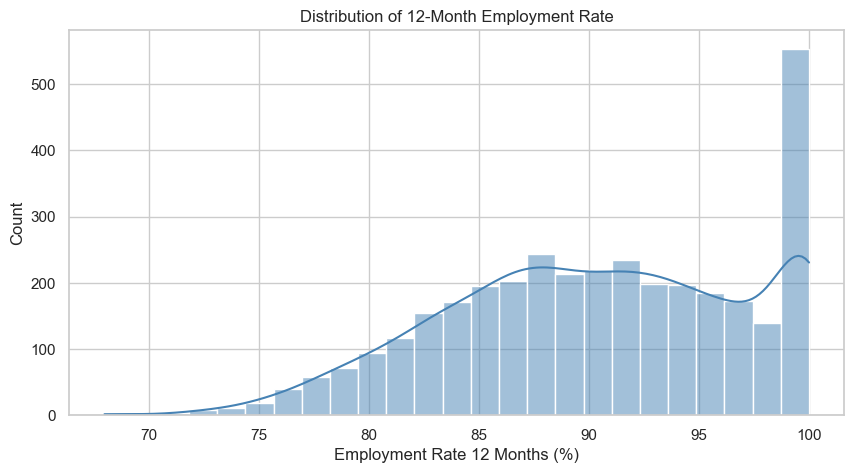

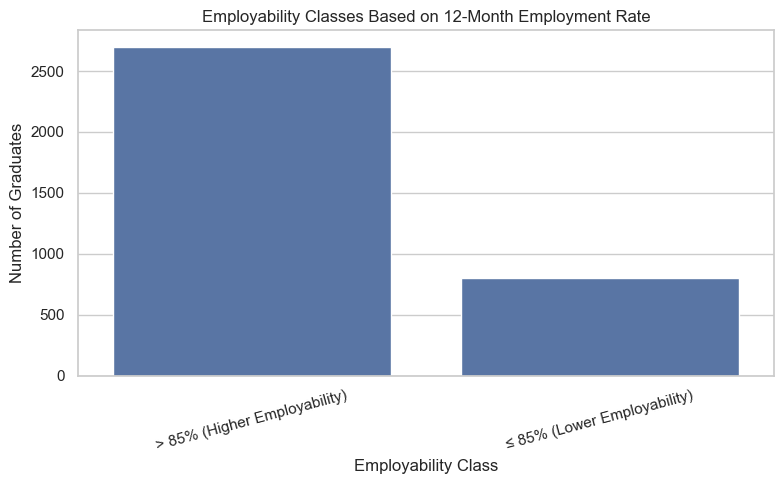

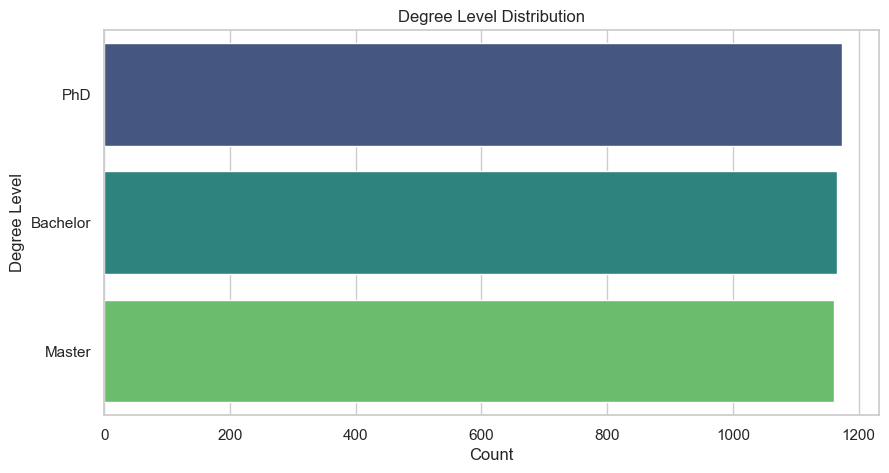

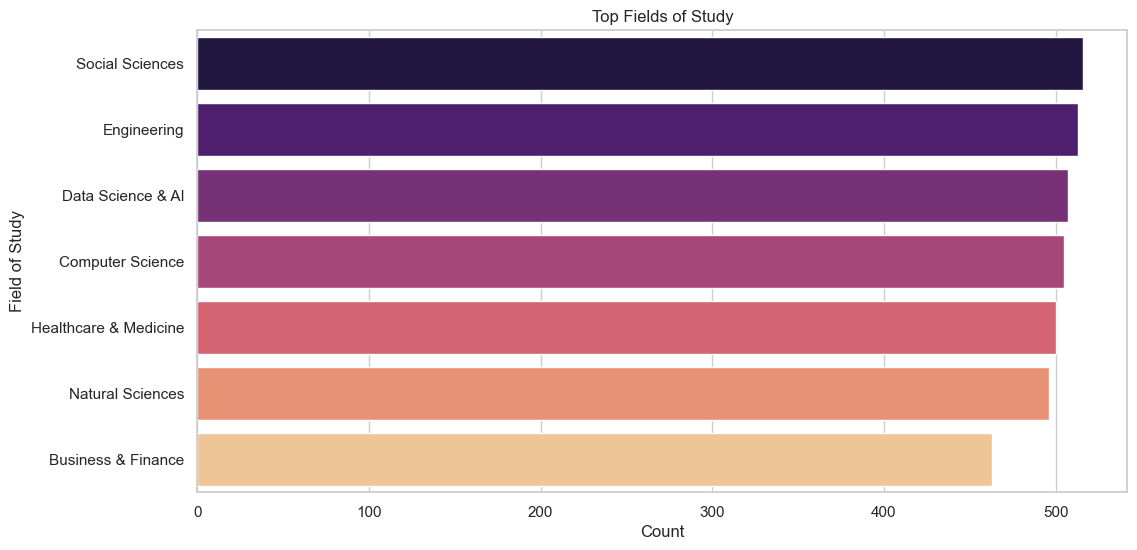

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df['Employment_Rate_12_Months (%)'], bins=25, kde=True, color='steelblue')
plt.title('Distribution of 12-Month Employment Rate')
plt.xlabel('Employment Rate 12 Months (%)')
plt.ylabel('Count')
plt.show()

# Create binary class
clean_df['Employability_Class'] = clean_df['Employment_Rate_12_Months (%)'].apply(
    lambda x: 0 if x <= 85 else 1
)

# Optional: label for readability
clean_df['Employability_Label'] = clean_df['Employability_Class'].map({
    0: '≤ 85% (Lower Employability)',
    1: '> 85% (Higher Employability)'
})

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(
    data=clean_df,
    x='Employability_Label'
)
plt.title('Employability Classes Based on 12-Month Employment Rate')
plt.xlabel('Employability Class')
plt.ylabel('Number of Graduates')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=clean_df, y='Degree_Level', order=clean_df['Degree_Level'].value_counts().index, palette='viridis')
plt.title('Degree Level Distribution')
plt.xlabel('Count')
plt.ylabel('Degree Level')
plt.show()

plt.figure(figsize=(12, 6))
top_fields = clean_df['Field_of_Study'].value_counts().nlargest(8).index
sns.countplot(data=clean_df[clean_df['Field_of_Study'].isin(top_fields)], y='Field_of_Study', order=top_fields, palette='magma')
plt.title('Top Fields of Study')
plt.xlabel('Count')
plt.ylabel('Field of Study')
plt.show()

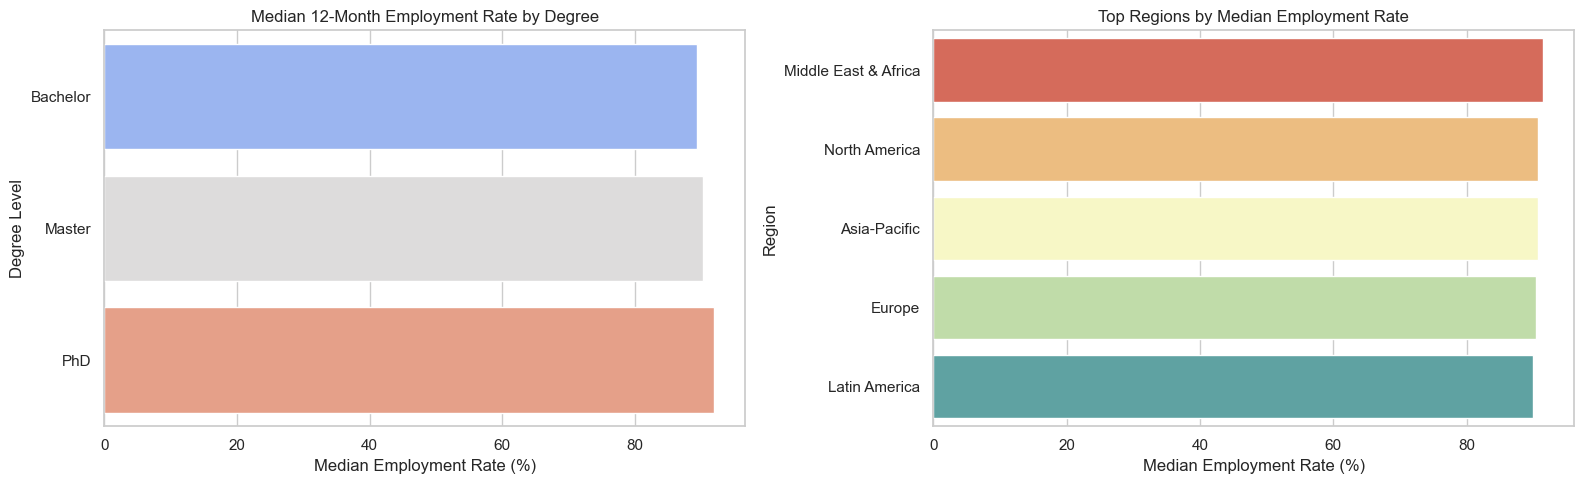

In [7]:
pivot_degree = clean_df.groupby('Degree_Level')['Employment_Rate_12_Months (%)'].median().reset_index()
pivot_region = clean_df.groupby('Region')['Employment_Rate_12_Months (%)'].median().nlargest(12).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=pivot_degree, x='Employment_Rate_12_Months (%)', y='Degree_Level', palette='coolwarm', ax=axes[0])
axes[0].set_title('Median 12-Month Employment Rate by Degree')
axes[0].set_xlabel('Median Employment Rate (%)')
axes[0].set_ylabel('Degree Level')

sns.barplot(data=pivot_region, x='Employment_Rate_12_Months (%)', y='Region', palette='Spectral', ax=axes[1])
axes[1].set_title('Top Regions by Median Employment Rate')
axes[1].set_xlabel('Median Employment Rate (%)')
axes[1].set_ylabel('Region')
plt.tight_layout()
plt.show()

## 4. Feature engineering and target definition
Create model-ready features, define the employability target variables, and split the data into training and test sets.

In [8]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    degree_ord = {'Bachelor': 1, 'Master': 2, 'PhD': 3, 'Unknown': 1}
    result['Degree_Level_Ordinal'] = result['Degree_Level'].map(degree_ord).fillna(1)
    result['Years_Since_Graduation'] = np.maximum(result['Year'] - result['Graduation_Year'], 0)
    result['Salary_per_Experience'] = np.where(result['Years_Since_Graduation'] > 0, result['Average_Starting_Salary_USD'] / result['Years_Since_Graduation'], result['Average_Starting_Salary_USD'])
    result['High_Demand_Skill'] = (result['Skill_Demand_Score (1–100)'] >= 70).astype(int)
    result['High_Reputation'] = (result['Employer_Reputation_Score (1–100)'] >= 65).astype(int)
    result['High_Remote'] = (result['Remote_Work_Availability (%)'] >= 50).astype(int)
    result['Aggregate_Score'] = (result['Demand_x_Reputation'] + result['Demand_x_Remote'] + result['Reputation_x_Remote']) / 3
    return result

feature_df = build_features(clean_df)
target_cutoff = feature_df['Employment_Rate_12_Months (%)'].quantile(0.25)
feature_df['Unemployability_Risk'] = (feature_df['Employment_Rate_12_Months (%)'] <= target_cutoff).astype(int)

print('Risk cutoff for binary classification:', round(target_cutoff, 2))
feature_df[['Degree_Level_Ordinal', 'Years_Since_Graduation', 'Skill_Count', 'Aggregate_Score', 'Unemployability_Risk']].head()

Risk cutoff for binary classification: 85.5


,Degree_Level_Ordinal,Years_Since_Graduation,Skill_Count,Aggregate_Score,Unemployability_Risk
0,1,0,3,19.140000,0
1,1,0,3,44.122000,0
2,2,0,3,14.926667,1
3,2,0,3,15.057000,0
4,3,0,3,43.536667,0


In [9]:
feature_columns = [
    'Degree_Level_Ordinal',
    'Years_Since_Graduation',
    'Average_Starting_Salary_USD',
    'Skill_Demand_Score (1–100)',
    'Employer_Reputation_Score (1–100)',
    'Remote_Work_Availability (%)',
    'Skill_Count',
    'Demand_x_Reputation',
    'Demand_x_Remote',
    'Reputation_x_Remote',
    'Aggregate_Score'
]
categorical_features = [col for col in ['Region', 'Field_of_Study', 'Top_Industry'] if col in feature_df.columns]

X = feature_df[feature_columns + categorical_features].copy()
y_class = feature_df['Unemployability_Risk']
y_reg = feature_df['Employment_Rate_12_Months (%)']

X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print('Training size:', X_train.shape)
print('Test size:', X_test.shape)

Training size: (2800, 14)
Test size: (700, 14)


## 5. Model training and selection
Train classification models to predict the risk of low employability and regression models to predict the employment rate itself.

In [10]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, feature_columns),
    ('cat', categorical_transformer, categorical_features)
])

classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

classification_results = []
for name, model in classification_models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train_cls)
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else pipeline.decision_function(X_test)
    classification_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_cls, y_pred),
        'Precision': precision_score(y_test_cls, y_pred, zero_division=0),
        'Recall': recall_score(y_test_cls, y_pred, zero_division=0),
        'F1': f1_score(y_test_cls, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test_cls, y_score),
    })

classification_results = pd.DataFrame(classification_results).sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)
classification_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.660000,0.421053,0.960000,0.585366,0.816675
1,Random Forest,0.750000,0.500000,0.262857,0.344569,0.780805
2,Gradient Boosting,0.734286,0.449541,0.280000,0.345070,0.775962


In [11]:
regression_models = {
    'Ridge Regression': Ridge(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

regression_results = []
for name, model in regression_models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train_reg)
    y_pred = pipeline.predict(X_test)
    regression_results.append({
        'Model': name,
        'R2': r2_score(y_test_reg, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        'MAE': mean_absolute_error(y_test_reg, y_pred),
    })

regression_results = pd.DataFrame(regression_results).sort_values(by=['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)
regression_results

,Model,R2,RMSE,MAE
0,Ridge Regression,-0.003885,6.319651,5.305846
1,Gradient Boosting Regressor,-0.018635,6.365910,5.314574
2,Random Forest Regressor,-0.069198,6.521990,5.442686


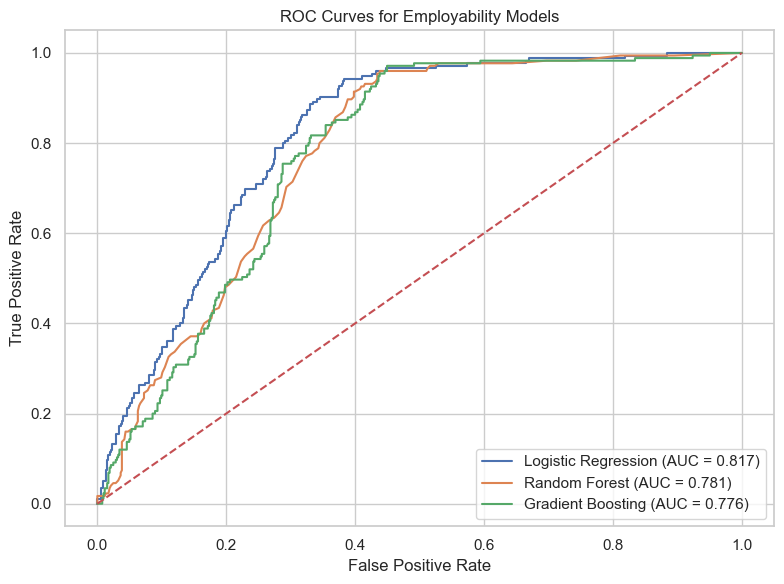

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Loop through all models
for model_name, model in classification_models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train_cls)
    
    # Get probabilities or decision scores
    if hasattr(pipeline, 'predict_proba'):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)
    
    # ROC computation
    fpr, tpr, _ = roc_curve(y_test_cls, y_score)
    auc = roc_auc_score(y_test_cls, y_score)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

# Diagonal baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curves for Employability Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../figures/roccurves.png", dpi=300)  
plt.show()

## 6. Model evaluation and fairness analysis
Assess the chosen model using performance metrics and subgroup analysis by region. The dataset does not include a gender field, so region-level fairness is used here.

Best classifier: Logistic Regression
Test accuracy: 0.66
Test ROC-AUC: 0.817


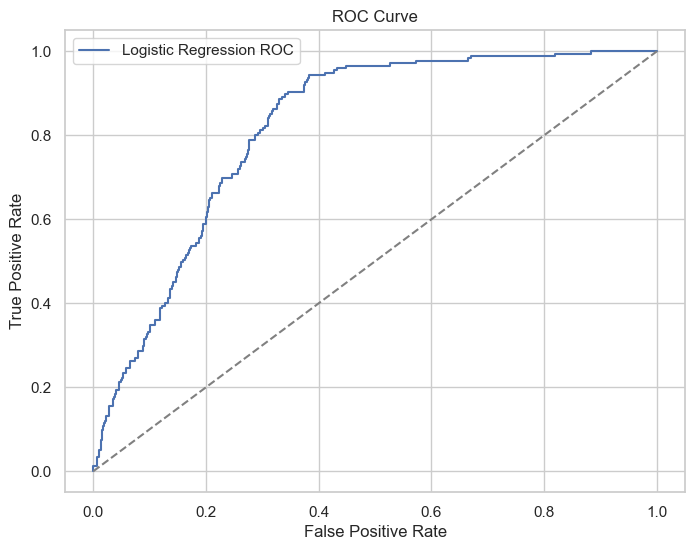

In [12]:
best_cls_name = classification_results.iloc[0]['Model']
best_cls_model = classification_models[best_cls_name]
best_cls_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', best_cls_model)])
best_cls_pipeline.fit(X_train, y_train_cls)

y_test_pred = best_cls_pipeline.predict(X_test)
y_test_score = best_cls_pipeline.predict_proba(X_test)[:, 1] if hasattr(best_cls_pipeline, 'predict_proba') else best_cls_pipeline.decision_function(X_test)

print('Best classifier:', best_cls_name)
print('Test accuracy:', round(accuracy_score(y_test_cls, y_test_pred), 3))
print('Test ROC-AUC:', round(roc_auc_score(y_test_cls, y_test_score), 3))

fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test_cls, y_test_score)
ax.plot(fpr, tpr, label=f'{best_cls_name} ROC')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()

In [13]:
region_analysis = []
X_test_with_meta = X_test.copy().reset_index(drop=True)
y_test_cls_with_meta = y_test_cls.reset_index(drop=True)
region_series = feature_df.loc[X_test.index, 'Region'].reset_index(drop=True)

for region, group_idx in region_series.groupby(region_series).groups.items():
    region_mask = group_idx
    if len(region_mask) < 20:
        continue
    region_y = y_test_cls_with_meta.loc[region_mask]
    region_pred = y_test_pred[region_mask]
    region_score = y_test_score[region_mask]
    region_analysis.append({
        'Region': region,
        'Count': len(region_mask),
        'Accuracy': accuracy_score(region_y, region_pred),
        'ROC_AUC': roc_auc_score(region_y, region_score) if len(np.unique(region_y)) > 1 else np.nan,
    })
region_performance = pd.DataFrame(region_analysis).sort_values(by='Count', ascending=False).reset_index(drop=True)
region_performance.head(12)

,Region,Count,Accuracy,ROC_AUC
0,Europe,158,0.702532,0.843478
1,Middle East & Africa,144,0.708333,0.828571
2,North America,141,0.645390,0.847709
3,Latin America,131,0.610687,0.786642
4,Asia-Pacific,126,0.619048,0.758976


## 7. Skill recommendation system design
Build a simple recommendation engine that suggests high-demand or missing skills based on the candidate profile and employability signals.

In [14]:
field_skill_map = {
    'Computer Science': ['Machine Learning', 'Cloud Computing', 'Data Structures'],
    'Data Science & AI': ['Machine Learning', 'Data Visualization', 'Statistics'],
    'Engineering': ['Project Management', 'CAD', 'Lean Six Sigma'],
    'Healthcare & Medicine': ['Clinical Research', 'Health Informatics', 'Patient Care'],
    'Business & Finance': ['Financial Modeling', 'Data Analysis', 'Digital Marketing'],
    'Natural Sciences': ['Experimental Design', 'Data Analysis', 'Research Methods'],
    'Social Sciences': ['Qualitative Research', 'Policy Analysis', 'Project Coordination'],
}

def recommend_skills(profile: pd.Series, top_skills_map: dict) -> list[str]:
    field = profile.get('Field_of_Study', 'Unknown')
    skills = {profile.get('Skill_1', ''), profile.get('Skill_2', ''), profile.get('Skill_3', '')}
    recommended = []
    for skill in top_skills_map.get(field, []):
        if skill not in skills:
            recommended.append(skill)
    if profile.get('Skill_Demand_Score (1–100)', 0) < 65:
        recommended.append('Market Research')
    if profile.get('Employer_Reputation_Score (1–100)', 0) < 60:
        recommended.append('Professional Networking')
    return recommended[:4]

sample_profile = feature_df.iloc[0]
print('Sample profile:')
print(sample_profile[['Field_of_Study', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_Demand_Score (1–100)', 'Employer_Reputation_Score (1–100)']])
print('Recommended skills:')
print(recommend_skills(sample_profile, field_skill_map))

Sample profile:
Field_of_Study                          Engineering
Skill_1                                     AutoCAD
Skill_2                              Lean Six Sigma
Skill_3                                      MATLAB
Skill_Demand_Score (1–100)                       69
Employer_Reputation_Score (1–100)                66
Name: 0, dtype: object
Recommended skills:
['Project Management', 'CAD']


## 8. Application integration and actionable insights
Summarize how this modelling work can be translated into an interactive application and policy recommendations.

### Application integration
- A dashboard can allow users to submit graduate profiles and receive a predicted employability score, risk category, and recommended skills.
- The existing Django app already imports the trained model from `employability-ai-system`. This notebook can support that pipeline by providing a cleaned feature engineering process and supporting documentation.
- An API endpoint can receive the same feature set used by the model pipeline and return predictions plus recommendations.

### Policy and university insights
- Degree level and field of study strongly correlate with 12-month employment outcomes.
- Skills with high demand and strong employer reputation are positive signals for employability.
- Region-level performance analysis highlights where students may need extra support, curriculum enhancements, or labor-market alignment.
- Recommendations should emphasize high-demand technical skills plus networking and portfolio-strengthening activities.

## Conclusion
This cleaned notebook combines the project objectives, data preparation, analytics, predictive modelling, fairness checks, and skill recommendations into one polished deliverable. It is now suitable for submission and presentation, with clear sections, reproducible code, and actionable findings.